# City/User/Campaign Report
This notebook focuses on user distribution, segment mix, and campaign involvement by city.

In [4]:
from pathlib import Path
import sqlite3

import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 120)

In [5]:
DB_PATH = Path('grab_vn_case.db')
assert DB_PATH.exists(), f'Database not found: {DB_PATH.resolve()}'

conn = sqlite3.connect(DB_PATH)

users = pd.read_sql_query('SELECT * FROM users', conn)
transactions = pd.read_sql_query('SELECT * FROM transactions', conn)

conn.close()

users['registration_date'] = pd.to_datetime(users['registration_date'], errors='coerce')
transactions['date'] = pd.to_datetime(transactions['date'], errors='coerce')

print('Loaded tables:')
print('users:', users.shape)
print('transactions:', transactions.shape)

Loaded tables:
users: (11800, 5)
transactions: (182313, 13)


## Users by City and Segment
Answers: percentage of user segment by city, and number of users for each city.

In [6]:
# Users by city (count and share)
users_by_city = (
    users.groupby('city', as_index=False)
    .agg(n_users=('user_id', 'count'))
    .sort_values('n_users', ascending=False)
    .reset_index(drop=True)
 )
users_by_city['pct_users'] = (
    users_by_city['n_users'] / users_by_city['n_users'].sum() * 100
 ).round(2)
display(users_by_city)

# User segment mix within each city (count and share)
segment_by_city = (
    users.groupby(['city', 'user_segment'], as_index=False)
    .agg(n_users=('user_id', 'count'))
)
segment_by_city['pct_in_city'] = (
    segment_by_city['n_users']
    / segment_by_city.groupby('city')['n_users'].transform('sum')
    * 100
 ).round(2)
display(segment_by_city.sort_values(['city', 'n_users'], ascending=[True, False]).reset_index(drop=True))

,city,n_users,pct_users
0,Ho Chi Minh City,6000,50.85
1,Hanoi,4000,33.90
2,Da Nang,1800,15.25


,city,user_segment,n_users,pct_in_city
0,Da Nang,Regular,511,28.39
1,Da Nang,Voucher Hunter,509,28.28
2,Da Nang,Occasional,498,27.67
3,Da Nang,High Value,282,15.67
4,Hanoi,Regular,1333,33.32
5,Hanoi,Occasional,967,24.18
6,Hanoi,Voucher Hunter,900,22.50
7,Hanoi,High Value,800,20.00
8,Ho Chi Minh City,Regular,1929,32.15
9,Ho Chi Minh City,Occasional,1603,26.72


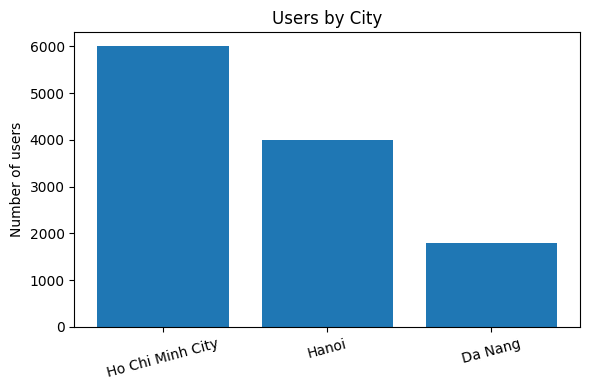

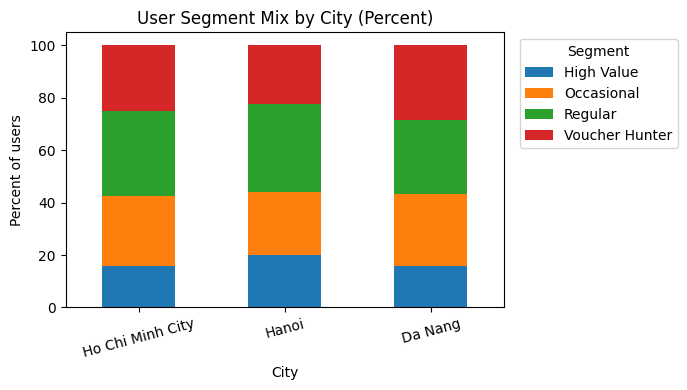

In [11]:
# Visuals: users by city and segment mix
plt.figure(figsize=(6, 4))
plt.bar(users_by_city['city'], users_by_city['n_users'])
plt.title('Users by City')
plt.ylabel('Number of users')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

segment_pivot = (
    segment_by_city
    .pivot(index='city', columns='user_segment', values='pct_in_city')
    .fillna(0)
    .loc[users_by_city['city']]
)
segment_pivot.plot(kind='bar', stacked=True, figsize=(7, 4))
plt.title('User Segment Mix by City (Percent)')
plt.ylabel('Percent of users')
plt.xlabel('City')
plt.xticks(rotation=15)
plt.legend(title='Segment', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

## Campaign Involvement by City
Answers: whether all users in HCMC were involved, and whether users in Da Nang/Hanoi were involved.

In [7]:
# Users with any promo-period transaction by city
promo_users_by_city = (
    transactions[transactions['period'] == 'Promo']
    .groupby('city', as_index=False)
    .agg(n_promo_users=('user_id', 'nunique'))
)
display(promo_users_by_city)

# Users with voucher redemption during promo, by city
promo_voucher_users_by_city = (
    transactions[(transactions['period'] == 'Promo') & (transactions['voucher_applied'] == 1)]
    .groupby('city', as_index=False)
    .agg(n_users_with_voucher=('user_id', 'nunique'))
)
display(promo_voucher_users_by_city)

# Join to compare against total users per city
promo_users_summary = (
    users_by_city
    .merge(promo_users_by_city, on='city', how='left')
    .merge(promo_voucher_users_by_city, on='city', how='left')
    .fillna({'n_promo_users': 0, 'n_users_with_voucher': 0})
)
promo_users_summary['pct_promo_users'] = (
    promo_users_summary['n_promo_users'] / promo_users_summary['n_users'] * 100
).round(2)
promo_users_summary['pct_voucher_users'] = (
    promo_users_summary['n_users_with_voucher'] / promo_users_summary['n_users'] * 100
).round(2)
display(promo_users_summary)

,city,n_promo_users
0,Da Nang,1798
1,Hanoi,3997
2,Ho Chi Minh City,5999


,city,n_users_with_voucher
0,Ho Chi Minh City,5978


,city,n_users,pct_users,n_promo_users,n_users_with_voucher,pct_promo_users,pct_voucher_users
0,Ho Chi Minh City,6000,50.85,5999,5978.0,99.98,99.63
1,Hanoi,4000,33.90,3997,0.0,99.92,0.00
2,Da Nang,1800,15.25,1798,0.0,99.89,0.00


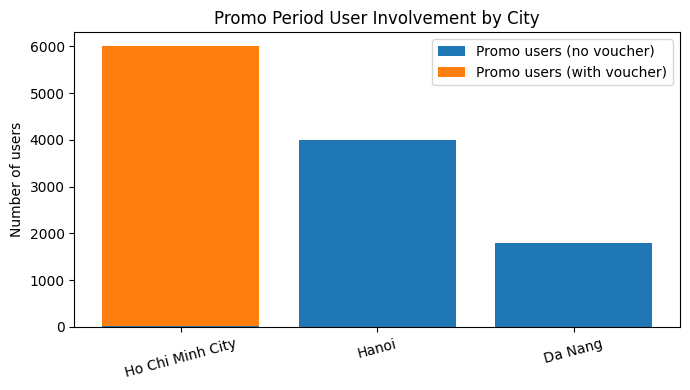

In [12]:
# Visuals: promo involvement by city
promo_plot = promo_users_summary.copy()
promo_plot['promo_no_voucher'] = promo_plot['n_promo_users'] - promo_plot['n_users_with_voucher']
promo_plot = promo_plot.set_index('city')

plt.figure(figsize=(7, 4))
plt.bar(promo_plot.index, promo_plot['promo_no_voucher'], label='Promo users (no voucher)')
plt.bar(promo_plot.index, promo_plot['n_users_with_voucher'], bottom=promo_plot['promo_no_voucher'], label='Promo users (with voucher)')
plt.title('Promo Period User Involvement by City')
plt.ylabel('Number of users')
plt.xticks(rotation=15)
plt.legend()
plt.tight_layout()
plt.show()

## Campaign Period Consistency
Answers: whether the campaign period differs by city and whether voucher activity appears outside HCMC.

In [8]:
# Voucher redemption date span by city
voucher_span_by_city = (
    transactions[transactions['voucher_applied'] == 1]
    .groupby('city', as_index=False)
    .agg(
        first_voucher_date=('date', 'min'),
        last_voucher_date=('date', 'max'),
        n_voucher_txn=('transaction_id', 'count')
    )
)
display(voucher_span_by_city)

# Promo-period transaction date span by city (any transaction)
promo_span_by_city = (
    transactions[transactions['period'] == 'Promo']
    .groupby('city', as_index=False)
    .agg(
        first_promo_date=('date', 'min'),
        last_promo_date=('date', 'max'),
        n_promo_txn=('transaction_id', 'count')
    )
)
display(promo_span_by_city)

,city,first_voucher_date,last_voucher_date,n_voucher_txn
0,Ho Chi Minh City,2024-02-12,2024-03-24,35015


,city,first_promo_date,last_promo_date,n_promo_txn
0,Da Nang,2024-02-12,2024-03-24,12006
1,Hanoi,2024-02-12,2024-03-24,24008
2,Ho Chi Minh City,2024-02-12,2024-03-24,54502


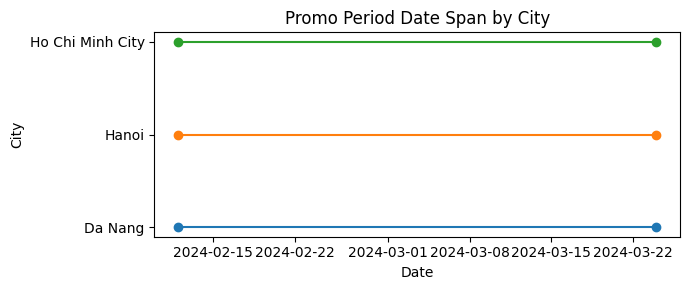

In [13]:
# Visuals: promo period span by city
span_plot = promo_span_by_city.copy()
span_plot = span_plot.sort_values('city')
plt.figure(figsize=(7, 3))
for idx, row in span_plot.iterrows():
    plt.plot([row['first_promo_date'], row['last_promo_date']], [row['city'], row['city']], marker='o')
plt.title('Promo Period Date Span by City')
plt.xlabel('Date')
plt.ylabel('City')
plt.tight_layout()
plt.show()

## User-Level Campaign Exposure
Answers: whether the effective campaign window differs across users in the same city.

In [9]:
# User-level promo window (first and last promo transaction)
user_promo_window = (
    transactions[transactions['period'] == 'Promo']
    .groupby(['city', 'user_id'], as_index=False)
    .agg(first_promo=('date', 'min'), last_promo=('date', 'max'))
)
user_promo_window['promo_days_active'] = (
    user_promo_window['last_promo'] - user_promo_window['first_promo']
 ).dt.days + 1
display(user_promo_window.head(10))

promo_window_summary = (
    user_promo_window
    .groupby('city')
    .agg(
        n_users=('user_id', 'count'),
        min_days=('promo_days_active', 'min'),
        p50_days=('promo_days_active', 'median'),
        p90_days=('promo_days_active', lambda s: s.quantile(0.9)),
        max_days=('promo_days_active', 'max')
    )
    .reset_index()
)
display(promo_window_summary)

,city,user_id,first_promo,last_promo,promo_days_active
0,Da Nang,6001,2024-02-13,2024-03-14,31
1,Da Nang,6002,2024-02-13,2024-03-16,33
2,Da Nang,6003,2024-02-19,2024-03-22,33
3,Da Nang,6004,2024-02-13,2024-03-04,21
4,Da Nang,6005,2024-02-19,2024-03-20,31
5,Da Nang,6006,2024-02-22,2024-02-29,8
6,Da Nang,6007,2024-02-13,2024-03-19,36
7,Da Nang,6008,2024-02-14,2024-02-28,15
8,Da Nang,6009,2024-02-17,2024-03-12,25
9,Da Nang,6010,2024-02-12,2024-03-23,41


,city,n_users,min_days,p50_days,p90_days,max_days
0,Da Nang,1798,1,33.0,40.0,42
1,Hanoi,3997,1,31.0,39.0,42
2,Ho Chi Minh City,5999,1,35.0,41.0,42


<Figure size 700x400 with 0 Axes>

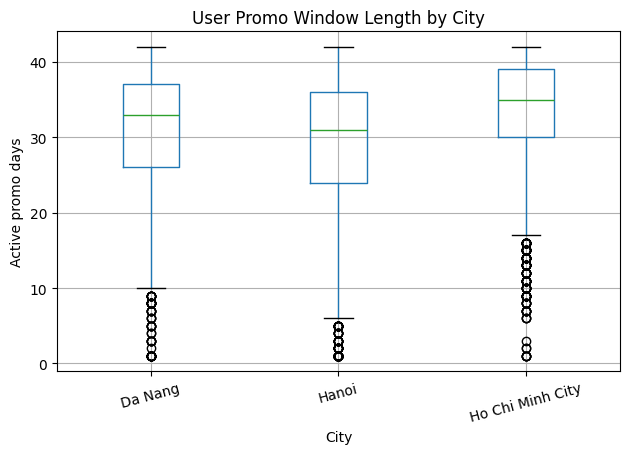

In [14]:
# Visuals: user-level promo window distribution
plt.figure(figsize=(7, 4))
user_promo_window.boxplot(column='promo_days_active', by='city')
plt.title('User Promo Window Length by City')
plt.suptitle('')
plt.xlabel('City')
plt.ylabel('Active promo days')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

## Quick Visuals
Fast scans to spot city differences.

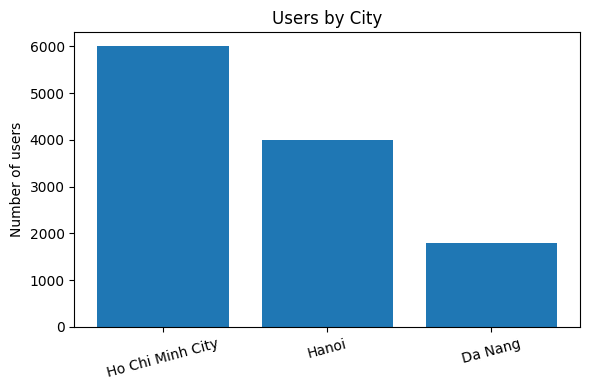

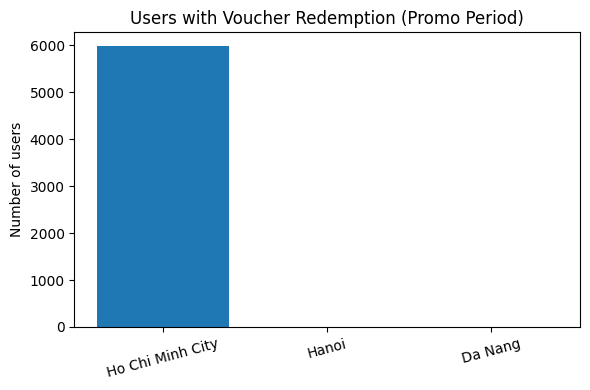

In [10]:
# Bar chart: user count by city
plt.figure(figsize=(6, 4))
plt.bar(users_by_city['city'], users_by_city['n_users'])
plt.title('Users by City')
plt.ylabel('Number of users')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

# Bar chart: promo voucher users by city
plt.figure(figsize=(6, 4))
plt.bar(promo_users_summary['city'], promo_users_summary['n_users_with_voucher'])
plt.title('Users with Voucher Redemption (Promo Period)')
plt.ylabel('Number of users')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()